## Data Cleaning

Choose 2023-08-15 in 2023q3 (You can choose another random day in 2023 q3)

In [1]:
from pathlib import Path
import pandas as pd

input_path = Path('spx_eod_202308.txt')
output_path = Path('spx_options_2023-08-15.csv')
target_date = '2023-08-15'

data = pd.read_csv(input_path, skipinitialspace=True)
data.columns = data.columns.str.strip()
filtered_data = data[data['[QUOTE_DATE]'].astype(str).eq(target_date)].copy()
filtered_data.to_csv(output_path, index=False)

print(f'Exported {len(filtered_data):,} rows to {output_path}')
print(f'Dates in export: {filtered_data["[QUOTE_DATE]"].unique().tolist()}')

Exported 8,085 rows to spx_options_2023-08-15.csv
Dates in export: ['2023-08-15']


Note that the definition of DTE: Days till Expiry in hours (assumes options expire on expiry date at 16:00). We need to first look at the descriptive statistics of DTE

In [2]:
import pandas as pd
df = pd.read_csv("spx_options_2023-08-15.csv")
dte = pd.to_numeric(df["[DTE]"], errors="coerce")
thresholds = [24, 168, 720]  # 1 day, 1 week, 1 month in hours

for threshold in thresholds:
    count = (dte >= threshold).sum()
    percentage = (dte >= threshold).mean() * 100

    print(
        f"DTE >= {threshold} hours: "
        f"{count:,} observations ({percentage:.1f}%)"
    )

DTE >= 24 hours: 5,217 observations (64.5%)
DTE >= 168 hours: 1,706 observations (21.1%)
DTE >= 720 hours: 177 observations (2.2%)


Use filters to clean the data (can be changed)
1. DTE >= 24
2. C_BID > 0 & P_BID >0
3. C_IV > 0 & P_IV >0
4. STRIKE_DISTANCE_PCT <= 0.20

In [6]:
import pandas as pd

input_path = "spx_options_2023-08-15.csv"
output_path = "spx_options_2023-08-15_filtered.csv"

df = pd.read_csv(input_path)
numeric_columns = [
    "[DTE]",
    "[C_BID]",
    "[P_BID]",
    "[C_IV]",
    "[P_IV]",
    "[STRIKE_DISTANCE_PCT]",
]
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors="coerce")

iv_sample = df[
    (df["[DTE]"] >= 24) &
    (df["[C_BID]"] > 0) &
    (df["[P_BID]"] > 0) &
    (df["[C_IV]"] > 0) &
    (df["[P_IV]"] > 0) &
    (df["[STRIKE_DISTANCE_PCT]"] <= 0.20)
].copy()

iv_sample.to_csv(output_path, index=False)

# EDA

descriptive statistics; distribution of DTE/Strike Distance Percentage/Call_IV Put_IV; Discrete volatility surfaces

In [14]:
import pandas as pd

eda_df = pd.read_csv("spx_options_2023-08-15_filtered.csv")

numeric_columns = [
    "[DTE]",
    "[STRIKE_DISTANCE_PCT]",
    "[C_IV]",
    "[P_IV]",
]
eda_df[numeric_columns] = eda_df[numeric_columns].apply(
    pd.to_numeric, errors="coerce"
)

eda_df[numeric_columns].describe()

,[DTE],[STRIKE_DISTANCE_PCT],[C_IV],[P_IV]
count,2703.000000,2703.000000,2703.000000,2703.000000
mean,141.777314,0.071380,0.197120,0.188335
std,180.676138,0.057219,0.052216,0.051437
min,24.000000,0.000000,0.114200,0.086000
25%,38.000000,0.023000,0.155555,0.147785
50%,94.040000,0.054000,0.189900,0.184010
75%,157.040000,0.115000,0.230420,0.224165
max,1585.040000,0.200000,0.425180,0.368110


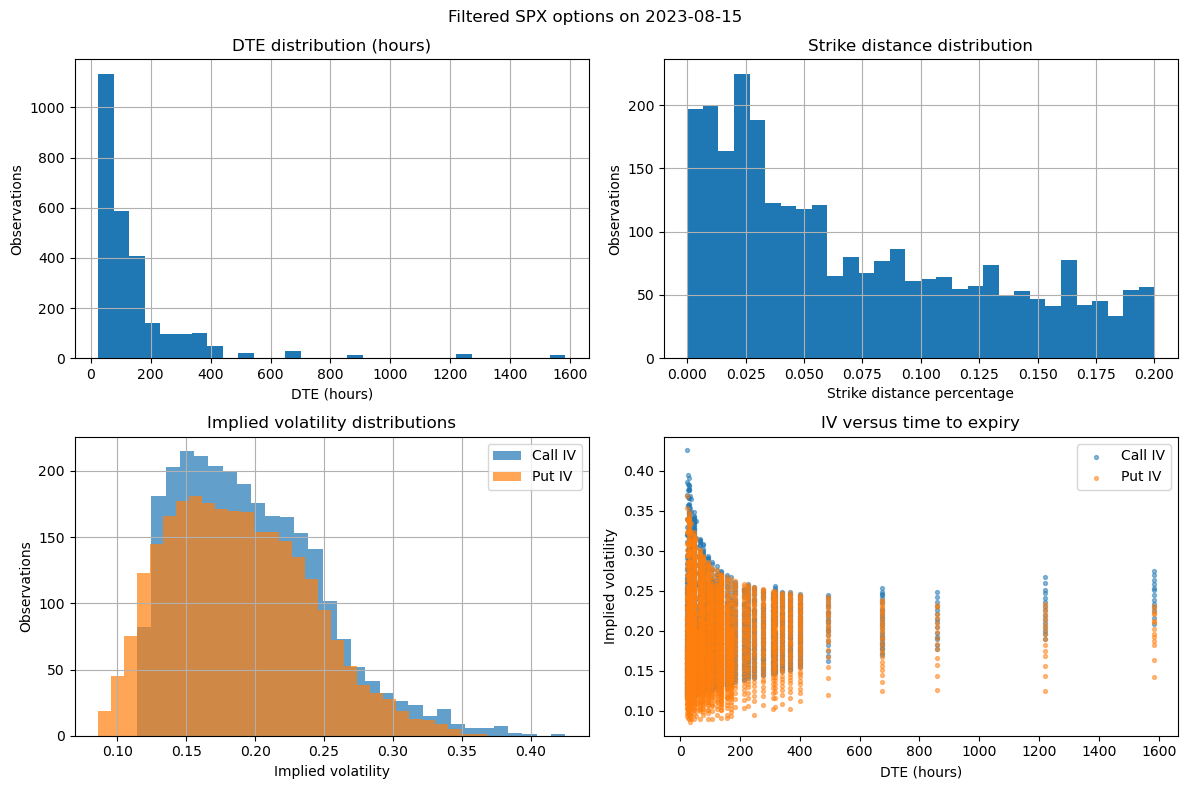

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

eda_df["[DTE]"].hist(bins=30, ax=axes[0, 0])
axes[0, 0].set_title("DTE distribution (hours)")
axes[0, 0].set_xlabel("DTE (hours)")
axes[0, 0].set_ylabel("Observations")

eda_df["[STRIKE_DISTANCE_PCT]"].hist(bins=30, ax=axes[0, 1])
axes[0, 1].set_title("Strike distance distribution")
axes[0, 1].set_xlabel("Strike distance percentage")
axes[0, 1].set_ylabel("Observations")

eda_df["[C_IV]"].hist(bins=30, alpha=0.7, label="Call IV", ax=axes[1, 0])
eda_df["[P_IV]"].hist(bins=30, alpha=0.7, label="Put IV", ax=axes[1, 0])
axes[1, 0].set_title("Implied volatility distributions")
axes[1, 0].set_xlabel("Implied volatility")
axes[1, 0].set_ylabel("Observations")
axes[1, 0].legend()

axes[1, 1].scatter(eda_df["[DTE]"], eda_df["[C_IV]"], s=8, alpha=0.5, label="Call IV")
axes[1, 1].scatter(eda_df["[DTE]"], eda_df["[P_IV]"], s=8, alpha=0.5, label="Put IV")
axes[1, 1].set_title("IV versus time to expiry")
axes[1, 1].set_xlabel("DTE (hours)")
axes[1, 1].set_ylabel("Implied volatility")
axes[1, 1].legend()

fig.suptitle("Filtered SPX options on 2023-08-15")
fig.tight_layout()

moneyness = [STRIKE] / [UNDERLYING_LAST]

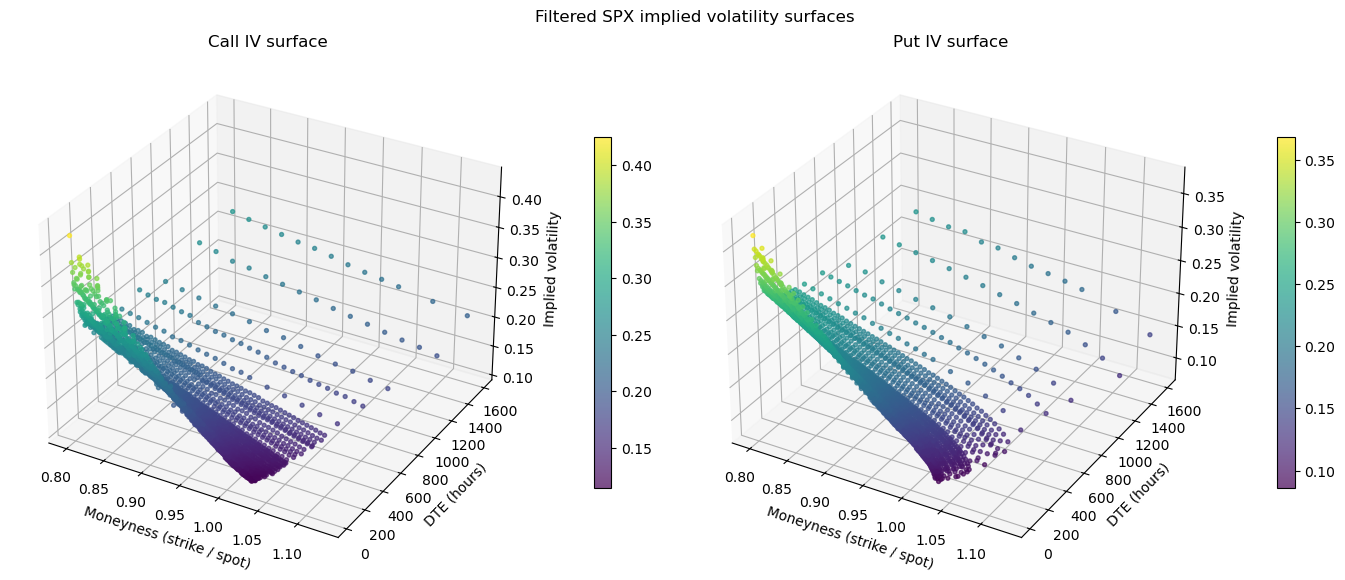

In [11]:
import matplotlib.pyplot as plt

surface_data = eda_df.copy()
surface_data["moneyness"] = (
    surface_data["[STRIKE]"] / surface_data["[UNDERLYING_LAST]"]
)

fig = plt.figure(figsize=(14, 6))

for plot_index, (iv_column, title) in enumerate(
    [("[C_IV]", "Call IV surface"), ("[P_IV]", "Put IV surface")],
    start=1,
):
    ax = fig.add_subplot(1, 2, plot_index, projection="3d")
    surface = surface_data.dropna(subset=[iv_column, "moneyness", "[DTE]"])
    points = ax.scatter(
        surface["moneyness"],
        surface["[DTE]"],
        surface[iv_column],
        c=surface[iv_column],
        cmap="viridis",
        s=8,
        alpha=0.7,
    )
    ax.set_xlabel("Moneyness (strike / spot)")
    ax.set_ylabel("DTE (hours)")
    ax.set_zlabel("Implied volatility")
    ax.set_title(title)
    fig.colorbar(points, ax=ax, shrink=0.65, pad=0.1)

fig.suptitle("Filtered SPX implied volatility surfaces")
fig.tight_layout()

# Implied Volatility (Bisection Search Method)


## 1. Prepare prices for a unified IV

We use the midpoint of the quoted bid and ask as the observed option price. Put-Call Parity gives a call-equivalent price from the put:

$$
C_{parity} = P + S e^{-qT} - K e^{-rT}
$$

The unified call price is the average of the quoted call midpoint and the parity-implied call midpoint. We then solve for one IV from this unified price. Here, `DTE` is measured in hours, so it is converted to years using `365 * 24`.

In [24]:
import numpy as np
import pandas as pd
from scipy.stats import norm

iv_df = pd.read_csv("spx_options_2023-08-15_filtered.csv")
price_columns = [
    "[DTE]",
    "[STRIKE]",
    "[UNDERLYING_LAST]",
    "[C_BID]",
    "[C_ASK]",
    "[P_BID]",
    "[P_ASK]",
]
iv_df[price_columns] = iv_df[price_columns].apply(pd.to_numeric, errors="coerce")

# Model assumptions. Change these inputs when a better rate or dividend estimate is available.
risk_free_rate = 0.05
dividend_yield = 0.00
hours_per_year = 365 * 24

iv_df["call_mid"] = (iv_df["[C_BID]"] + iv_df["[C_ASK]"]) / 2
iv_df["put_mid"] = (iv_df["[P_BID]"] + iv_df["[P_ASK]"]) / 2
iv_df["time_to_expiry"] = iv_df["[DTE]"] / hours_per_year

iv_df["parity_call_mid"] = (
    iv_df["put_mid"]
    + iv_df["[UNDERLYING_LAST]"] * np.exp(-dividend_yield * iv_df["time_to_expiry"])
    - iv_df["[STRIKE]"] * np.exp(-risk_free_rate * iv_df["time_to_expiry"])
)
iv_df["unified_call_price"] = (
    iv_df["call_mid"] + iv_df["parity_call_mid"]
) / 2

iv_df[["call_mid", "put_mid", "parity_call_mid", "unified_call_price"]].describe()

,call_mid,put_mid,parity_call_mid,unified_call_price
count,2703.000000,2703.000000,2703.000000,2703.000000
mean,415.505549,83.666315,351.068171,383.286860
std,284.412219,77.970483,267.306299,273.877559
min,15.950000,1.175000,1.005440,8.717650
25%,170.125000,26.350000,113.551427,142.998905
50%,364.300000,62.250000,297.634361,330.359618
75%,628.125000,118.525000,554.746565,594.913037
max,1531.950000,625.850000,1118.832431,1325.391215


## 2. Black-Scholes pricing and bisection search

For each row, the bisection search solves:

$$
C_{BS}(\sigma) - C_{unified} = 0
$$

The lower and upper volatility bounds are `1e-6` and `5.0` (500%). At each iteration, if the model price is below the target price, volatility must increase; otherwise, the upper bound moves down. The search stops when the price error is below the chosen tolerance.

In [20]:
def black_scholes_call(spot, strike, time_to_expiry, volatility, rate, dividend):
    """Return the Black-Scholes European call price."""
    if time_to_expiry <= 0:
        return max(spot - strike, 0.0)

    volatility_sqrt_time = volatility * np.sqrt(time_to_expiry)
    d1 = (
        np.log(spot / strike)
        + (rate - dividend + 0.5 * volatility ** 2) * time_to_expiry
    ) / volatility_sqrt_time
    d2 = d1 - volatility_sqrt_time

    return (
        spot * np.exp(-dividend * time_to_expiry) * norm.cdf(d1)
        - strike * np.exp(-rate * time_to_expiry) * norm.cdf(d2)
    )


def implied_volatility_bisection(
    target_price,
    spot,
    strike,
    time_to_expiry,
    rate,
    dividend,
    lower_volatility=1e-6,
    upper_volatility=5.0,
    tolerance=1e-6,
    max_iterations=100,
):
    """Solve for call IV with bisection; return NaN if no valid bracket exists."""
    values = [target_price, spot, strike, time_to_expiry]
    if any(pd.isna(value) for value in values) or time_to_expiry <= 0:
        return np.nan

    discounted_spot = spot * np.exp(-dividend * time_to_expiry)
    discounted_strike = strike * np.exp(-rate * time_to_expiry)
    no_arbitrage_lower_bound = max(discounted_spot - discounted_strike, 0.0)
    no_arbitrage_upper_bound = discounted_spot

    if target_price < no_arbitrage_lower_bound - tolerance:
        return np.nan
    if target_price > no_arbitrage_upper_bound + tolerance:
        return np.nan

    low = lower_volatility
    high = upper_volatility
    low_price = black_scholes_call(
        spot, strike, time_to_expiry, low, rate, dividend
    )
    high_price = black_scholes_call(
        spot, strike, time_to_expiry, high, rate, dividend
    )

    if target_price < low_price - tolerance or target_price > high_price + tolerance:
        return np.nan

    for _ in range(max_iterations):
        midpoint = (low + high) / 2
        midpoint_price = black_scholes_call(
            spot, strike, time_to_expiry, midpoint, rate, dividend
        )
        price_error = midpoint_price - target_price

        if abs(price_error) < tolerance:
            return midpoint
        if price_error < 0:
            low = midpoint
        else:
            high = midpoint

    return (low + high) / 2

## 3. Calculate the unified implied volatility

The unified IV is calculated by solving the Black-Scholes pricing equation using the Put-Call-Parity-adjusted call price.

In [28]:
iv_df["unified_iv"] = iv_df.apply(
    lambda row: implied_volatility_bisection(
        target_price=row["unified_call_price"],
        spot=row["[UNDERLYING_LAST]"],
        strike=row["[STRIKE]"],
        time_to_expiry=row["time_to_expiry"],
        rate=risk_free_rate,
        dividend=dividend_yield,
    ),
    axis=1,
)

iv_df["moneyness"] = iv_df["[STRIKE]"] / iv_df["[UNDERLYING_LAST]"]

valid_iv = iv_df["unified_iv"].notna()
print(f"Valid unified IV observations: {valid_iv.sum():,} / {len(iv_df):,}")
print(f"Valid IV percentage: {valid_iv.mean():.1%}")
print("\nUnified IV summary:")
print(iv_df.loc[valid_iv, ["unified_iv"]].describe())

Valid unified IV observations: 2,703 / 2,703
Valid IV percentage: 100.0%

Unified IV summary:
        unified_iv
count  2703.000000
mean      1.028419
std       0.335581
min       0.483704
25%       0.759110
50%       0.982044
75%       1.248105
max       2.336412


Saved IV results to spx_options_2023-08-15_unified_iv.csv


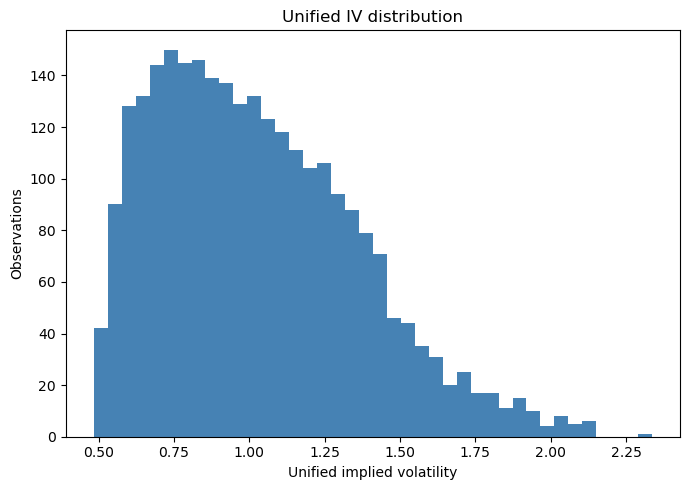

In [26]:
output_columns = [
    "[QUOTE_DATE]",
    "[EXPIRE_DATE]",
    "[DTE]",
    "[STRIKE]",
    "[UNDERLYING_LAST]",
    "moneyness",
    "call_mid",
    "put_mid",
    "parity_call_mid",
    "unified_call_price",
    "unified_iv",
    "[C_IV]",
    "[P_IV]",
]

iv_output_path = "spx_options_2023-08-15_unified_iv.csv"
iv_df[output_columns].to_csv(iv_output_path, index=False)

plt.figure(figsize=(7, 5))
plt.hist(iv_df["unified_iv"].dropna(), bins=40, color="steelblue")
plt.title("Unified IV distribution")
plt.xlabel("Unified implied volatility")
plt.ylabel("Observations")
plt.tight_layout()

print(f"Saved IV results to {iv_output_path}")

## 5. Continuous unified implied volatility surface

The raw option quotes are discrete points. This cell uses linear interpolation only inside the convex hull of the observed `(moneyness, DTE)` points. The scatter plot shows the original unified IV observations, while the surface plot shows the interpolated representation.

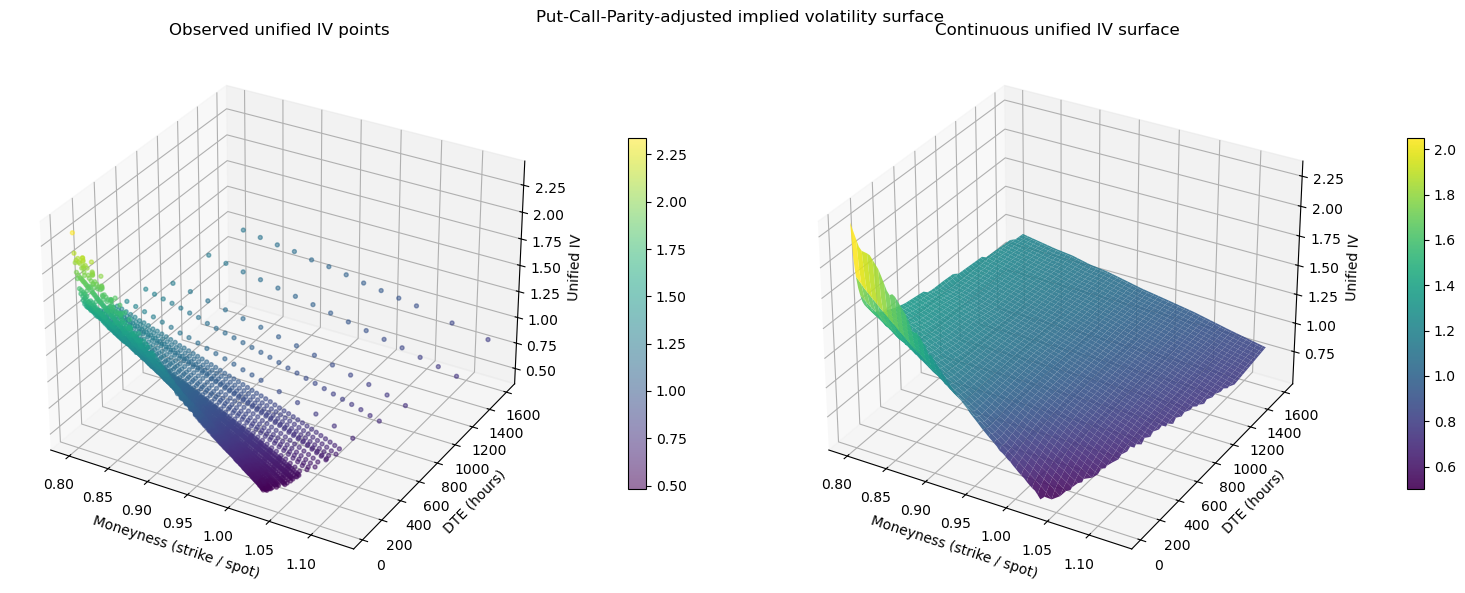

In [27]:
from scipy.interpolate import griddata

surface = iv_df.dropna(subset=["moneyness", "[DTE]", "unified_iv"]).copy()

moneyness_values = surface["moneyness"].to_numpy()
dte_values = surface["[DTE]"].to_numpy()
unified_iv_values = surface["unified_iv"].to_numpy()

moneyness_grid = np.linspace(
    moneyness_values.min(), moneyness_values.max(), 100
)
dte_grid = np.linspace(dte_values.min(), dte_values.max(), 100)
X, Y = np.meshgrid(moneyness_grid, dte_grid)

Z = griddata(
    points=(moneyness_values, dte_values),
    values=unified_iv_values,
    xi=(X, Y),
    method="linear",
)

fig = plt.figure(figsize=(16, 6))

ax_points = fig.add_subplot(1, 2, 1, projection="3d")
point_plot = ax_points.scatter(
    moneyness_values,
    dte_values,
    unified_iv_values,
    c=unified_iv_values,
    cmap="viridis",
    s=8,
    alpha=0.55,
)
ax_points.set_title("Observed unified IV points")
ax_points.set_xlabel("Moneyness (strike / spot)")
ax_points.set_ylabel("DTE (hours)")
ax_points.set_zlabel("Unified IV")
fig.colorbar(point_plot, ax=ax_points, shrink=0.65, pad=0.1)

ax_surface = fig.add_subplot(1, 2, 2, projection="3d")
surface_plot = ax_surface.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis",
    linewidth=0,
    antialiased=True,
    alpha=0.9,
)
ax_surface.set_title("Continuous unified IV surface")
ax_surface.set_xlabel("Moneyness (strike / spot)")
ax_surface.set_ylabel("DTE (hours)")
ax_surface.set_zlabel("Unified IV")
fig.colorbar(surface_plot, ax=ax_surface, shrink=0.65, pad=0.1)

fig.suptitle("Put-Call-Parity-adjusted implied volatility surface")
fig.tight_layout()
fig.savefig("spx_options_2023-08-15_unified_iv_surface.png", dpi=150)
plt.show()